In [16]:
def get_clf_eval(y_test,pred=None,pred_proba=None):
    confusion=confusion_matrix(y_test,pred)
    accuracy=np.round(accuracy_score(y_test,pred),2)
    precision=np.round(precision_score(y_test,pred),2)
    recall=np.round(recall_score(y_test,pred),2)
    f1=np.round(f1_score(y_test,pred),2)
    #roc-auc추가
    roc_auc=np.round(roc_auc_score(y_test,pred_proba),2)
    print('오차행렬')
    print(confusion)
    print(f'정확도{accuracy},정밀도{precision},재현율{recall},f1_점수{f1},auc{roc_auc}')

In [5]:
# 목표 당뇨병 여부를 판단
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,precision_score,recall_score,roc_auc_score
from sklearn.metrics import f1_score,confusion_matrix,precision_recall_curve,roc_curve
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

diabets_data=pd.read_csv('diabetes.csv')
print(diabets_data['Outcome'].value_counts())
diabets_data.head(3)

Outcome
0    500
1    268
Name: count, dtype: int64


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1


In [4]:
#전처리
diabets_data.info()
# 모든 데이터에 null값이 없고 전부숫자, 해석에 있어서도 별도의 피처인코딩은 필요없어보임

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [17]:
X=diabets_data.iloc[:,:-1]
y=diabets_data['Outcome']


X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=156,stratify=y)

#로지스틱회귀로 학습, 예측 및 평가 수행

lr=LogisticRegression(solver='liblinear')
lr.fit(X_train,y_train)
pred=lr.predict(X_test)
pred_proba=lr.predict_proba(X_test)[:,1]

get_clf_eval(y_test,pred,pred_proba)

오차행렬
[[87 13]
 [22 32]]
정확도0.77,정밀도0.71,재현율0.59,f1_점수0.65,auc0.81


In [18]:
#전체 데이터의 65%가 negetive이니까 ,재현율을 위주로 성능을 조절하기로함

pred_proba_c1=lr.predict_proba(X_test)[:,1]
precision_recall_curve(y_test,pred_proba_c1) #정밀도,재현율 커브는 y_test와 확률값을 요구함

(array([0.35064935, 0.34640523, 0.34210526, 0.34437086, 0.34666667,
        0.34899329, 0.35135135, 0.3537415 , 0.35616438, 0.35862069,
        0.36111111, 0.36363636, 0.36619718, 0.36170213, 0.36428571,
        0.36690647, 0.36956522, 0.37226277, 0.375     , 0.37777778,
        0.38059701, 0.38345865, 0.38636364, 0.38931298, 0.39230769,
        0.3875969 , 0.390625  , 0.39370079, 0.3968254 , 0.4       ,
        0.40322581, 0.40650407, 0.40983607, 0.41322314, 0.41666667,
        0.42016807, 0.42372881, 0.42735043, 0.43103448, 0.43478261,
        0.43859649, 0.44247788, 0.44642857, 0.45045045, 0.45454545,
        0.4587156 , 0.46296296, 0.46728972, 0.47169811, 0.47619048,
        0.47115385, 0.47572816, 0.48039216, 0.47524752, 0.48      ,
        0.48484848, 0.48979592, 0.48453608, 0.48958333, 0.49473684,
        0.5       , 0.50537634, 0.5       , 0.50549451, 0.5       ,
        0.50561798, 0.51136364, 0.51724138, 0.51162791, 0.51764706,
        0.52380952, 0.53012048, 0.53658537, 0.53

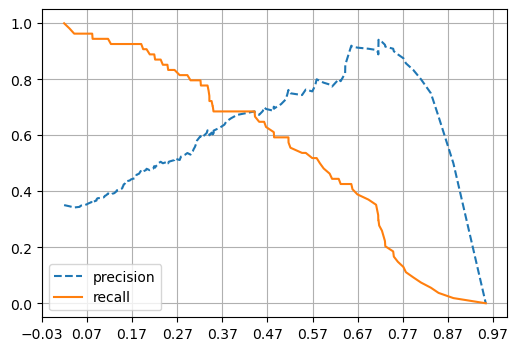

In [19]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

def precision_recall_curve_plot(y_test,pred_proba_c1):
    precision,recall,threshold=precision_recall_curve(y_test,pred_proba_c1)

    # x축을 threshold값, y축은 정밀도, 재현율 값으로  plot 실행
    plt.figure(figsize=(6,4))
    threshold_boundary=threshold.shape[0]
    plt.plot(threshold,precision[0:threshold_boundary],label='precision',linestyle='--')
    plt.plot(threshold,recall[0:threshold_boundary],label='recall')

    # threshold 값 X 축의 Scale을 0.1로 변겅
    start,end = plt.xlim()
    plt.xticks(np.round(np.arange(start,end,0.1),2))

    # x축,y축 label과 legend, 그리고 grid 설정
    plt.grid()
    plt.legend()
    plt.show()

precision_recall_curve_plot(y_test,pred_proba_c1)

In [22]:
#0.47로 맞추면 재현율과 정밀도과 균형을 맞추겠지만,  두개의 지표모두 0.7도 안된다.. 임계값을 인위적으로조작하기전 데이터 상태부터 
diabets_data.describe()
#포도당,혈압 이런수치들이 0이되는게 말이 안된다고 생각함 

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


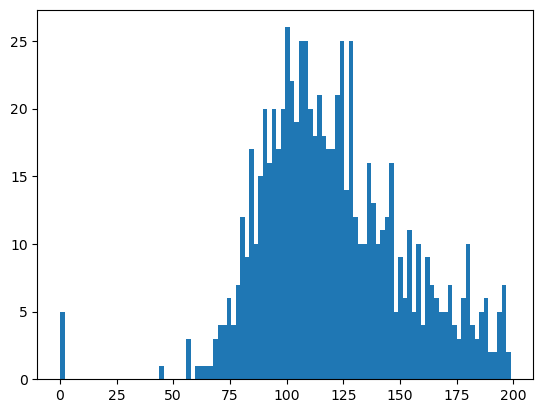

In [24]:
plt.hist(diabets_data['Glucose'],bins=100)
plt.show()

In [36]:
# 0값을 검사
zero_features=['Glucose','BloodPressure','SkinThickness','Insulin','BMI']
# 전체 데이터 대비 비율
total_count=diabets_data['Glucose'].count()

#피처별로 반복하면서 전체대비 비율
for i in zero_features:
    zero_count=diabets_data[diabets_data[i]==0][i].count()
    zero_ratio=np.round((zero_count/total_count)*100,2)
    print(f'{i}의0갯수는 {zero_count}이고,zero비율은{zero_ratio}%이다.')
#0의 값의비율이 높아서 삭제보다는 평균값 대체를 고려함
#우선 0을 대체하기전 성능지표가 매우 안좋은편에속한다고 생각
# 왜 0을 대체해야하는가? 0이 무엇이문제인가?
# 모델이 성능이 안좋은이유 1. 데이터자체의문제 2. 중요한변수가 빠져있음 3.변수의 크기 차이를 고려하지 않음 4.데이터 자체에서 두 집단이 많이 겹침
# 이상하다고 생각하는 이유는 1.도메인지식차원에서 특정변수의 값이 0인게 말이안되기 때문이다. 혈당0이 정상적인 사람인가?
# 잘못된 데이터 0이 모델에 주는 영향, 모델은 독립변수와 종속변수의 관계속에서 계수를 찾는데, 혈당이 높으면 당뇨병이 높다는걸배우다가, 혈당이 0인데도 당뇨병이 있다
#고하면 혈당과 당뇨병의 관계가 흐려진다.
# 또한 계산식과정에서 혈당이 0인 사람이 당뇨가 아닌 재현율이 떨어짐


Glucose의0갯수는 5이고,zero비율은0.65%이다.
BloodPressure의0갯수는 35이고,zero비율은4.56%이다.
SkinThickness의0갯수는 227이고,zero비율은29.56%이다.
Insulin의0갯수는 374이고,zero비율은48.7%이다.
BMI의0갯수는 11이고,zero비율은1.43%이다.


In [38]:
mean_zero_features=diabets_data[zero_features].mean()
diabets_data[zero_features]=diabets_data[zero_features].replace(0,mean_zero_features)

In [61]:
X=diabets_data.iloc[:,:-1]
y=diabets_data.iloc[:,-1]

#로지스틱회귀는 데이터 변수의 일괄적 스케일링을 적용하는게좋다

scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)

X_train,X_test,y_train,y_test=train_test_split(X_scaled,y,test_size=0.2,random_state=156,stratify=y)

lr=LogisticRegression()
lr.fit(X_train,y_train)
pred=lr.predict(X_test)
pred_proba=lr.predict_proba(X_test)[:,1]

get_clf_eval(y_test,pred,pred_proba)

오차행렬
[[90 10]
 [21 33]]
정확도0.8,정밀도0.77,재현율0.61,f1_점수0.68,auc0.84


In [77]:
from sklearn.preprocessing import Binarizer
def get_eval_by_thresholds(y_test,pred_proba_c1, thresholds):
    for i in thresholds:
        binar=Binarizer(threshold=i)           
        custom_pred=binar.fit_transform(pred_proba_c1) 
        get_clf_eval(y_test,custom_pred,pred_proba_c1) 

In [78]:
thresholds=[0.3,0.33,0.36,0.39,0.42,0.45,0.48,0.5]
pred_proba=lr.predict_proba(X_test)
get_eval_by_thresholds(y_test,pred_proba[:,1].reshape(-1,1),thresholds)
#수치상 0.48임계값부분이 가장 성과지표를 유지하면서 재현율을 약간 상승시키는 부분으로 보임

오차행렬
[[67 33]
 [11 43]]
정확도0.71,정밀도0.57,재현율0.8,f1_점수0.66,auc0.84
오차행렬
[[72 28]
 [12 42]]
정확도0.74,정밀도0.6,재현율0.78,f1_점수0.68,auc0.84
오차행렬
[[76 24]
 [15 39]]
정확도0.75,정밀도0.62,재현율0.72,f1_점수0.67,auc0.84
오차행렬
[[78 22]
 [16 38]]
정확도0.75,정밀도0.63,재현율0.7,f1_점수0.67,auc0.84
오차행렬
[[84 16]
 [18 36]]
정확도0.78,정밀도0.69,재현율0.67,f1_점수0.68,auc0.84
오차행렬
[[85 15]
 [18 36]]
정확도0.79,정밀도0.71,재현율0.67,f1_점수0.69,auc0.84
오차행렬
[[88 12]
 [19 35]]
정확도0.8,정밀도0.74,재현율0.65,f1_점수0.69,auc0.84
오차행렬
[[90 10]
 [21 33]]
정확도0.8,정밀도0.77,재현율0.61,f1_점수0.68,auc0.84


In [81]:
binarizer=Binarizer(threshold=0.48)
prd_th_048=binarizer.fit_transform(pred_proba[:,1].reshape(-1,1))

get_clf_eval(y_test,prd_th_048,pred_proba[:,1])

오차행렬
[[88 12]
 [19 35]]
정확도0.8,정밀도0.74,재현율0.65,f1_점수0.69,auc0.84
